In [1]:
import numpy as np
from matplotlib import pyplot as plt
from covariate_filtering import covariate_filtering
from scipy.linalg import fractional_matrix_power
from scipy.stats import wishart

In [2]:
random_state = 1
np.random.seed(random_state)

n = 100
d = 50

In [3]:
# Hyperparameters for clean synthetic data
w_true = np.random.normal(0, 1, d)
Sigma = wishart.rvs(df=d, scale=np.eye(d))
label_noise_std = 1

X_clean = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)
whitening_matrix = fractional_matrix_power(Sigma, -0.5)

In [20]:
n_eps = 100
epsilons = np.linspace(0.01, 0.49, n_eps)

inlier_avgs = np.zeros(n_eps)
outlier_avgs = np.zeros(n_eps)

for i, epsilon in enumerate(epsilons):
    outlier_idx = np.random.choice(n, int(n * epsilon), replace=False)
    inlier_idx = np.setdiff1d(np.arange(n), outlier_idx)

    X_corrupted = np.copy(X_clean)
    X_corrupted[outlier_idx] += np.random.normal(10, 1, size=(1, d))
    X_white = X_corrupted @ whitening_matrix

    omega = covariate_filtering(X_white, epsilon)

    inlier_avgs[i] = np.mean(omega[inlier_idx])
    outlier_avgs[i] = np.mean(omega[outlier_idx])

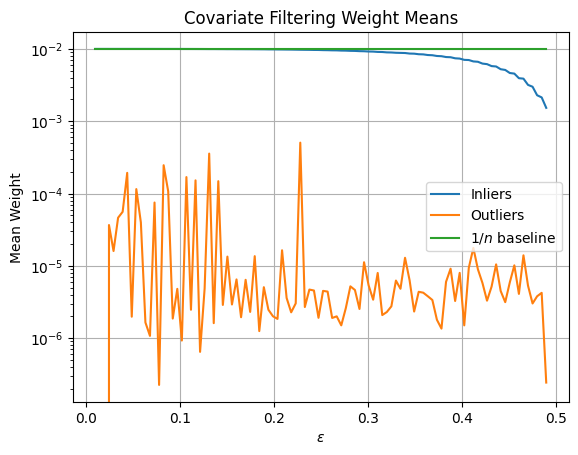

In [21]:
plt.title('Covariate Filtering Weight Means')
plt.xlabel('$\\epsilon$')
plt.ylabel('Mean Weight')
plt.semilogy(epsilons, inlier_avgs, label='Inliers')
plt.semilogy(epsilons, outlier_avgs, label='Outliers')
plt.semilogy(epsilons, np.ones(n_eps) / n, label='$1/n$ baseline')
plt.grid()
plt.legend()
plt.show()